# 第6回: OLS, Ridge, LASSO による回帰モデル演習

## 基本情報

- 主題: OLS, Ridge 回帰, LASSO 回帰の比較
- 位置づけ: 第5回の California housing dataset を用いた回帰分析の続き
- 使用データ: California housing dataset
- 分析課題: 住宅価格予測を題材に、正則化の役割と特徴量選択を理解する
- 到達目標:
  - OLS, Ridge, LASSO の違いを説明できる
  - なぜ標準化が必要なのかを説明できる
  - Ridge が係数を小さくすることを確認できる
  - LASSO が一部の係数を 0 にすることを確認できる
  - `alpha` を変えたときに、予測精度と係数がどう変わるかを確認できる
  - LassoCV を使って `alpha` をデータから選ぶ流れを実行できる

This notebook includes code and explanations generated with OpenAI Codex.

---

## 1. 今回の方針

前回は、California housing dataset を使って、Python, NumPy, pandas, scikit-learn の基本的な流れを確認した。

前回の基本形は次の通りである。

```python

X_train, X_test, y_train, y_test = train_test_split(X, y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

```

今回は、この流れを保ったまま、回帰モデルを比較する。

比較するモデルは次の 3 つである。

| モデル | 特徴 |
|---|---|
| OLS | 通常の線形回帰 |
| Ridge | 係数が大きくなりすぎることを抑える |
| LASSO | 係数を 0 にすることがあり、特徴量選択の効果を持つ |

特に、３つのモデルの差異を強調するために、人工的なノイズ変数を追加する。
その上で、LASSO が不要そうな変数を落とす様子を確認する。

---

## 2. なぜ OLS だけでは不十分なことがあるのか

線形回帰は、特徴量 $x_1, x_2, \ldots, x_p$ を使って目的変数 $y$ を予測するモデルである。

$$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p
$$

OLS は、予測値 $\hat{y}$ と実際の値 $y$ のずれが小さくなるように係数を決める。
具体的には、残差平方和を小さくする。

$$
\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

OLS は非常に基本的で重要な方法である。
しかし、次のような場合には問題が起きやすい。

- 特徴量の数が多い
- 似たような特徴量が複数ある
- ノイズのような不要な特徴量が含まれている
- 特徴量同士の相関が強い
- 学習データにはよく合うが、テストデータでは性能が落ちる

たとえば、住宅価格を予測するときに、所得、人口、緯度、経度、部屋数などに加えて、意味のない乱数の列を大量に入れたとする。
OLS は、それらのノイズ変数にも係数をつけてしまい、データによっては、偶然の相関を拾ってしまうことがある。
これが過学習につながる。

---

## 3. 正則化の考え方

Ridge と LASSO は、OLS の目的関数にペナルティを加える方法である。
このような方法を **正則化** という。

直感的には、両方とも共通して「予測誤差を小さくしたいが、係数が大きくなりすぎるのも避けたい」という考え方である。

係数が大きすぎるモデルは、学習データの細かい揺れに反応しすぎている可能性がある。
正則化は、係数を抑えることで、モデルを安定させる。

---

### 3.1 Ridge 回帰

Ridge 回帰は、係数の二乗和にペナルティをかける。

$$
\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p}\beta_j^2
$$

ここで、$\alpha$ は正則化の強さを表す。

- $\alpha$ が小さい: OLS に近い
- $\alpha$ が大きい: 係数をより強く小さくする

Ridge の特徴は、係数を小さくするが、厳密に $0$ にはなりにくい。
結果、すべての特徴量を少しずつ使うモデルになりやすい。

---

### 3.2 LASSO 回帰

LASSO 回帰は、係数の絶対値の和にペナルティをかける。

$$
\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p}|\beta_j|
$$

LASSO も $\alpha$ が大きいほど、係数を強く小さくする。

Ridge と異なる重要な点は、LASSO では一部の係数が厳密に $0$ になる点である。
LASSO は **特徴量選択** として使える。

---

### 3.3 OLS, Ridge, LASSO の比較

| モデル | ペナルティ | 係数の特徴 | 使いどころ |
|---|---|---|---|
| OLS | なし | すべての特徴量に自由に係数をつける | 基本モデル |
| Ridge | 係数の二乗和 | 係数を全体的に小さくする | 多くの変数を少しずつ使いたい |
| LASSO | 係数の絶対値の和 | 一部の係数を $0$ にする | 不要変数を落としたい |

今回の演習では、人工的にノイズ変数を追加する。
そのうえで、

- OLS はノイズ変数にも係数をつけるのか
- Ridge は係数を小さくするのか
- LASSO はノイズ変数の係数を $0$ にするのか

を確認する。

---

## 4. ライブラリの読み込み

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

グラフの見た目を少し整える。

In [4]:
plt.style.use("ggplot")

---

## 5. データの読み込み

第5回と同じ California housing dataset を使う。

In [5]:
housing = fetch_california_housing(as_frame=True)

X = housing.data.copy()
y = housing.target.copy()

`as_frame=True` を指定すると、pandas の DataFrame と Series として取得できる。

確認する。

In [6]:
print(type(X))
print(type(y))
print(X.shape)
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(20640, 8)
(20640,)


先頭を見る。

In [7]:
display(X.head())
display(y.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


特徴量名を確認する。

In [8]:
X.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

目的変数は住宅価格中央値であり、単位は 10 万ドルである。

In [9]:
y.describe()

,MedHouseVal
count,20640.000000
mean,2.068558
std,1.153956
min,0.149990
25%,1.196000
50%,1.797000
75%,2.647250
max,5.000010


---

## 6. 人工的なノイズ変数を追加する

今回の主題は、正則化が不要な特徴量にどう反応するかを見ることである。
そこで、元の特徴量に加えて、人工的なノイズ変数を追加する。

ノイズ変数とは、目的変数を説明する本質的な意味を持たない変数である。
ここでは乱数で作る。

In [10]:
np.random.seed(42)

n_noise_features = 20

まず、互いに強く相関するノイズ変数を 2 つ作る。

In [11]:
noise_0 = np.random.randn(len(X))
noise_1 = 0.99 * noise_0 + 0.01 * np.random.randn(len(X))

X["noise_0"] = noise_0
X["noise_1"] = noise_1

さらに、独立なノイズ変数を追加する。

In [12]:
for i in range(2, n_noise_features):
    X[f"noise_{i}"] = np.random.randn(len(X))

元の特徴量とノイズ特徴量を分けて記録しておく。

In [13]:
original_features = [col for col in X.columns if not col.startswith("noise_")]
noise_features = [col for col in X.columns if col.startswith("noise_")]

確認する。

In [14]:
print("Original X shape:", housing.data.shape)
print("Augmented X shape:", X.shape)
print("Number of original features:", len(original_features))
print("Number of noise features   :", len(noise_features))
print("Correlation between noise_0 and noise_1:", round(X[["noise_0", "noise_1"]].corr().iloc[0, 1], 4))

display(X.head())

Original X shape: (20640, 8)
Augmented X shape: (20640, 28)
Number of original features: 8
Number of noise features   : 20
Correlation between noise_0 and noise_1: 0.9999


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,noise_0,noise_1,...,noise_10,noise_11,noise_12,noise_13,noise_14,noise_15,noise_16,noise_17,noise_18,noise_19
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,0.496714,0.476512,...,-0.931604,-0.346367,-0.401429,-0.642130,0.378650,0.345086,-1.406857,0.435348,-2.835930,1.216889
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,-0.138264,-0.132633,...,0.541254,-0.762588,1.067248,-2.556423,0.095425,0.217871,-1.030771,0.965547,1.317531,0.052153
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,0.647689,0.640498,...,-0.067800,-0.388925,-1.468053,-0.392929,-1.162823,0.440864,0.913514,0.952406,0.031577,-1.950098
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,1.523030,1.520229,...,1.380369,-0.936149,0.315741,-2.195058,0.430398,-0.468004,0.265117,0.052450,-1.391486,0.482017
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,-0.234153,-0.220089,...,-0.620669,0.122479,-0.212700,-1.064814,-0.772666,1.874458,-0.754902,0.450487,-1.584496,0.826385


この時点で、元の 8 個の特徴量に、20 個のノイズ特徴量が追加されている。
つまり、合計 28 個の特徴量で住宅価格を予測する。

---

## 7. train / test に分割する

学習データとテストデータに分ける。

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

確認する。

In [16]:
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (16512, 28) (16512,)
Test : (4128, 28) (4128,)


ここでは、データの 20% をテストデータにしている。

---

## 8. 標準化

Ridge や LASSO では、標準化が重要である。

理由は、正則化のペナルティが係数に直接かかるからである。
特徴量のスケールが違うと、同じ係数でも意味が変わってしまう。
そこで、学習データの平均と標準偏差を使って標準化する。

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ここで重要なのは、テストデータに対して `fit_transform()` ではなく `transform()` を使うことである。

- 学習データ: `fit_transform()`
- テストデータ: `transform()`

データリークを防止するため

---

## 9. OLS, Ridge, LASSO を比較する

### 9.1 モデルを定義する

3 つのモデルを辞書にまとめる。

In [18]:
models = {
    "OLS": LinearRegression(),
    "Ridge(alpha=1.0)": Ridge(alpha=1.0),
    "Lasso(alpha=0.01)": Lasso(alpha=0.01, max_iter=20000)
}

`alpha` は正則化の強さである。
LASSO の `alpha` を小さめの値から試してみる。
<!-- California housing dataset の目的変数は 10 万ドル単位であり、Diabetes dataset とはスケールが異なる。 -->

---

### 9.2 学習、予測、評価をまとめて実行する

In [19]:
results = []
coef_dict = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    coef = pd.Series(model.coef_, index=X.columns)

    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "nonzero_coef": int((coef != 0).sum()),
        "zero_coef": int((coef == 0).sum())
    })

    coef_dict[name] = coef

results_df = pd.DataFrame(results)
coef_df = pd.DataFrame(coef_dict)

display(results_df)
display(coef_df)

,model,MAE,RMSE,R2,nonzero_coef,zero_coef
0,OLS,0.533676,0.746340,0.574924,28,0
1,Ridge(alpha=1.0),0.533642,0.746268,0.575006,28,0
2,Lasso(alpha=0.01),0.535373,0.740506,0.581544,9,19


,OLS,Ridge(alpha=1.0),Lasso(alpha=0.01)
MedInc,0.854774,0.854708,0.801082
HouseAge,0.122716,0.122794,0.127158
AveRooms,-0.295055,-0.294875,-0.162904
AveBedrms,0.340189,0.339936,0.206409
Population,-0.002277,-0.002246,-0.000000
AveOccup,-0.040626,-0.040647,-0.030580
Latitude,-0.896532,-0.895699,-0.789878
Longitude,-0.869588,-0.868781,-0.755487
noise_0,-0.273749,-0.124789,-0.000000
noise_1,0.271367,0.122406,-0.000000


見るべき点は次の通りである。

- RMSE はどのモデルで小さいか
- $R^2$ はどのモデルで大きいか
- LASSO では 0 になった係数があるか
- ノイズ変数の係数はどうなっているか

---

## 10. 係数を比較する

係数を表で見る。

In [20]:
coef_df.loc[original_features]

,OLS,Ridge(alpha=1.0),Lasso(alpha=0.01)
MedInc,0.854774,0.854708,0.801082
HouseAge,0.122716,0.122794,0.127158
AveRooms,-0.295055,-0.294875,-0.162904
AveBedrms,0.340189,0.339936,0.206409
Population,-0.002277,-0.002246,-0.000000
AveOccup,-0.040626,-0.040647,-0.030580
Latitude,-0.896532,-0.895699,-0.789878
Longitude,-0.869588,-0.868781,-0.755487


ノイズ特徴量の係数を見る。

In [21]:
coef_df.loc[noise_features].head(10)

,OLS,Ridge(alpha=1.0),Lasso(alpha=0.01)
noise_0,-0.273749,-0.124789,-0.000000
noise_1,0.271367,0.122406,-0.000000
noise_2,-0.005410,-0.005401,-0.000000
noise_3,0.001900,0.001896,0.000000
noise_4,-0.015625,-0.015625,-0.004790
noise_5,-0.007337,-0.007321,-0.000000
noise_6,-0.014689,-0.014666,-0.004942
noise_7,-0.001945,-0.001949,-0.000000
noise_8,0.003288,0.003286,0.000000
noise_9,0.000769,0.000773,0.000000


棒グラフで可視化する。

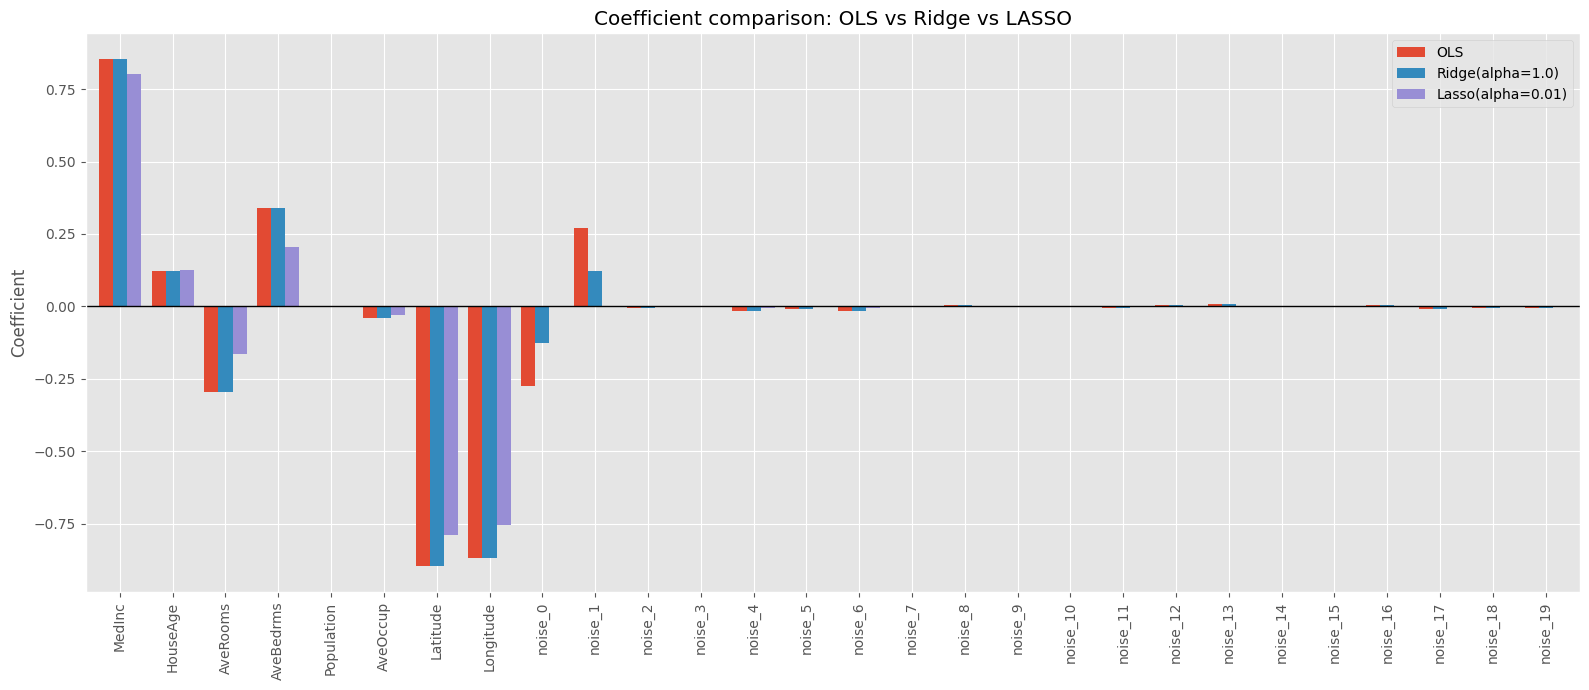

In [22]:
coef_df.plot(kind="bar", figsize=(16, 7), width=0.8)
plt.axhline(0, color="black", linewidth=1)
plt.title("Coefficient comparison: OLS vs Ridge vs LASSO")
plt.ylabel("Coefficient")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

係数のグラフを見ると、次の点を確認しやすい。

- OLS の係数は大きく振れやすいか
- Ridge の係数は OLS より小さくなっているか
- LASSO では係数が 0 になっている変数があるか

ただし、係数は標準化後の特徴量に対する係数である。
そのため、元の単位での効果としてそのまま解釈してはいけない。

---

## 11. LASSO で alpha を変える

LASSO では、`alpha` の値によって結果が大きく変わる。

- `alpha` が小さい: OLS に近く、係数が残りやすい
- `alpha` が大きい: 正則化が強くなり、0 になる係数が増えやすい

いくつかの `alpha` を試してみる。

In [23]:
alphas = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1]

summary = []
coef_table = pd.DataFrame(index=X.columns)

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=20000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)

    coef = pd.Series(lasso.coef_, index=X.columns)
    coef_table[f"alpha={alpha}"] = coef

    summary.append({
        "alpha": alpha,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "nonzero_coef": int((coef != 0).sum()),
        "zero_coef": int((coef == 0).sum())
    })

summary_df = pd.DataFrame(summary)

display(summary_df)
display(coef_table)

,alpha,MAE,RMSE,R2,nonzero_coef,zero_coef
0,0.0001,0.533609,0.746145,0.575146,27,1
1,0.0003,0.533577,0.745924,0.575398,27,1
2,0.0010,0.533477,0.745187,0.576236,26,2
3,0.0030,0.533426,0.743399,0.578267,19,9
4,0.0100,0.535373,0.740506,0.581544,9,19
5,0.0300,0.553708,0.755257,0.564707,6,22
6,0.1000,0.622201,0.824396,0.481361,3,25


,alpha=0.0001,alpha=0.0003,alpha=0.001,alpha=0.003,alpha=0.01,alpha=0.03,alpha=0.1
MedInc,0.854233,0.853184,0.849492,0.838850,0.801082,0.736442,0.710598
HouseAge,0.122796,0.122957,0.123512,0.124610,0.127158,0.133593,0.106453
AveRooms,-0.293772,-0.291127,-0.281836,-0.255383,-0.162904,-0.000000,-0.000000
AveBedrms,0.338856,0.336191,0.326839,0.300088,0.206409,0.024007,0.000000
Population,-0.002144,-0.001899,-0.001043,-0.000000,-0.000000,-0.000000,-0.000000
AveOccup,-0.040565,-0.040381,-0.039740,-0.037809,-0.030580,-0.010859,-0.000000
Latitude,-0.895281,-0.893040,-0.885242,-0.863554,-0.789878,-0.545493,-0.011469
Longitude,-0.868335,-0.865958,-0.857679,-0.834509,-0.755487,-0.502144,-0.000000
noise_0,-0.002299,-0.002101,-0.001409,-0.000000,-0.000000,-0.000000,-0.000000
noise_1,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000


確認すること:

- `alpha` が大きくなると、0 になる係数は増えるか
- RMSE は単調に小さくなるか
- 係数が少ないモデルほど、必ず予測精度が高いと言えるか

一般に、`alpha` を大きくするとモデルは単純になる。
しかし、単純にしすぎると重要な変数まで落としてしまい、予測精度が悪くなることがある。

---

## 12. LASSO の係数パス

`alpha` を連続的に変えたときに、各係数がどう変わるかを見る。
これを係数パスという。

In [24]:
alphas_plot = np.logspace(-4, -0.5, 100)
coefs = []

for alpha in alphas_plot:
    lasso = Lasso(alpha=alpha, max_iter=20000)
    lasso.fit(X_train_scaled, y_train)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

可視化する。

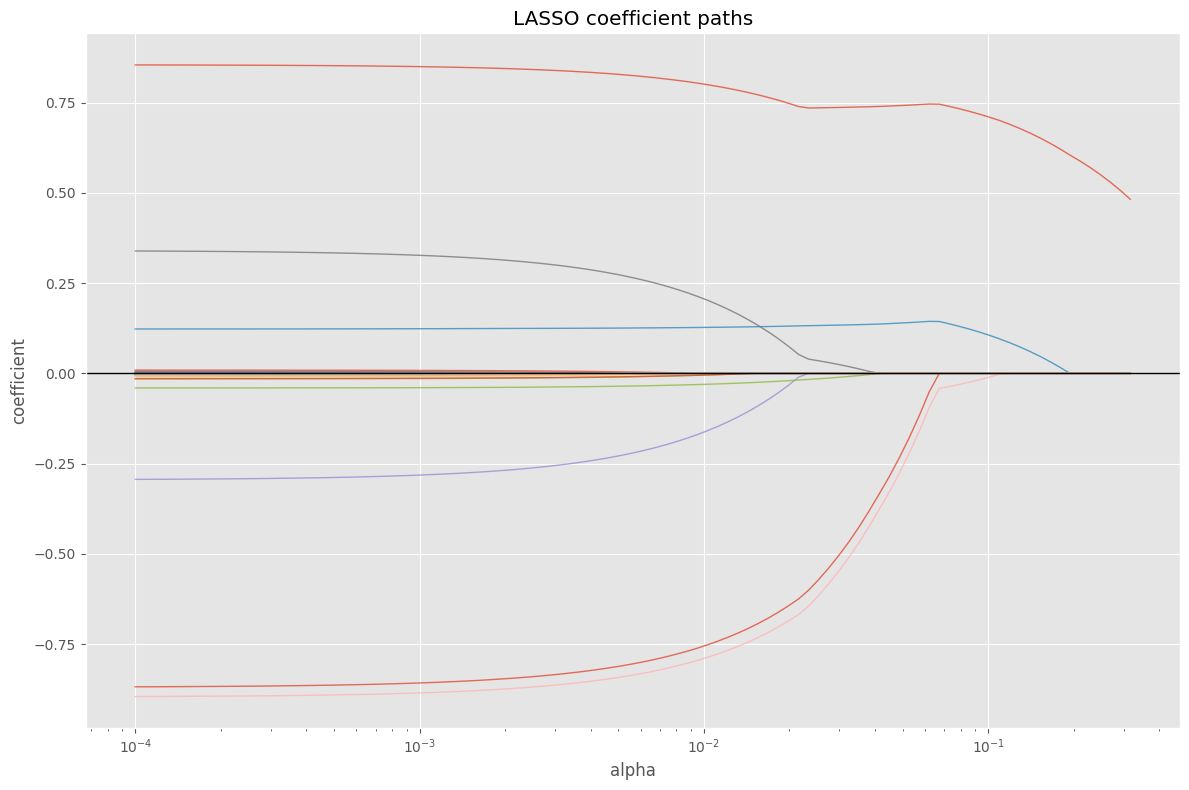

In [25]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(X.columns):
    plt.plot(alphas_plot, coefs[:, i], linewidth=1, alpha=0.8)

plt.xscale("log")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("alpha")
plt.ylabel("coefficient")
plt.title("LASSO coefficient paths")
plt.tight_layout()
plt.show()

このグラフでは、横軸が `alpha`、縦軸が係数である。
`alpha` が大きくなるにつれて、多くの係数が 0 に近づく。

LASSO の特徴は、単に係数が小さくなるだけでなく、ちょうど 0 になる係数が出ることである。

---

## 13. LassoCV で alpha を自動選択する

ここまでは、`alpha` を手で決めていた。
しかし実務では、どの `alpha` がよいかを事前に知ることができない。

そこで、Cross-validationを使って `alpha` を選ぶ。
scikit-learn では `LassoCV` を使う。

In [26]:
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso_cv.fit(X_train_scaled, y_train)

LassoCV(cv=5, max_iter=20000, random_state=42)

予測と評価を行う。

In [27]:
y_pred_cv = lasso_cv.predict(X_test_scaled)
coef_cv = pd.Series(lasso_cv.coef_, index=X.columns)

print("Best alpha:", lasso_cv.alpha_)
print("Test MAE  :", mean_absolute_error(y_test, y_pred_cv))
print("Test RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_cv)))
print("Test R2   :", r2_score(y_test, y_pred_cv))
print("Non-zero coefficients:", int((coef_cv != 0).sum()))
print("Zero coefficients    :", int((coef_cv == 0).sum()))

Best alpha: 0.001844683761878051
Test MAE  : 0.533410133858293
Test RMSE : 0.7443729602796461
Test R2   : 0.5771617005102495
Non-zero coefficients: 23
Zero coefficients    : 5


絶対値が大きい係数を確認する。

In [28]:
display(coef_cv.sort_values(key=np.abs, ascending=False))

,0
Latitude,-0.875861
Longitude,-0.847721
MedInc,0.845044
AveBedrms,0.315567
AveRooms,-0.270643
HouseAge,0.124176
AveOccup,-0.038974
noise_4,-0.013533
noise_6,-0.012813
noise_13,0.007241


`LassoCV` は、複数の `alpha` を試し、交差検証でよいものを選ぶ。
ただし、選ばれた `alpha` が常に理論的に正しいという意味ではない。
あくまで、指定したデータ分割と評価基準のもとで選ばれた値である。

---

## 14. LassoCV の CV 誤差パスを可視化する

`LassoCV` は、複数の `alpha` について交差検証を行い、平均的な予測誤差が小さい `alpha` を選ぶ。
そのため、どの `alpha` が選ばれたかだけでなく、各 fold での誤差がどう変化したかを見ると理解しやすい。

`LassoCV` の `mse_path_` には、各 `alpha` と各 fold における MSE が保存されている。

In [29]:
lasso_cv.mse_path_.shape

(100, 5)

可視化する。

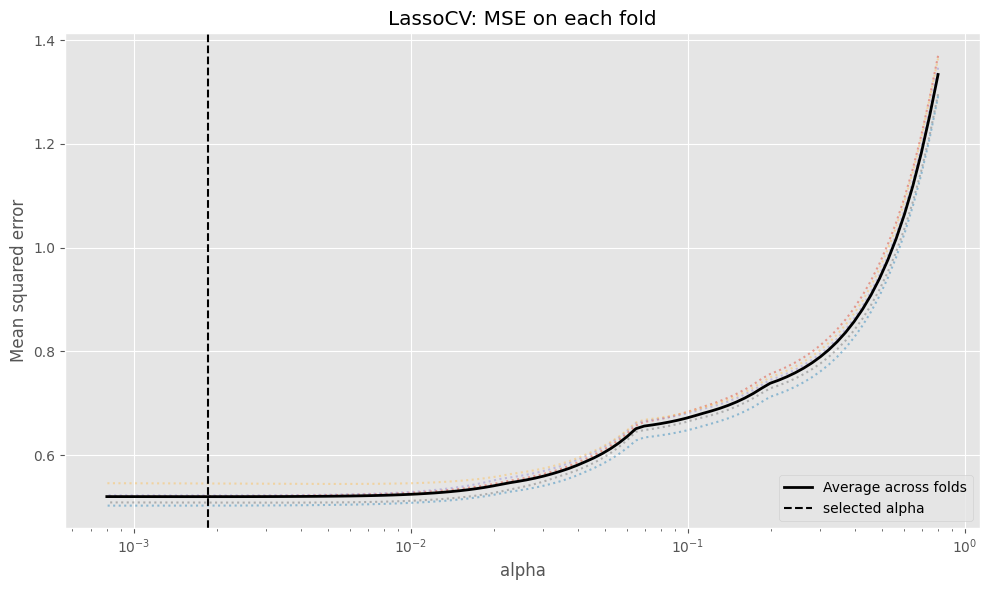

In [30]:
plt.figure(figsize=(10, 6))

plt.semilogx(lasso_cv.alphas_, lasso_cv.mse_path_, ":", alpha=0.5)
plt.semilogx(
    lasso_cv.alphas_,
    lasso_cv.mse_path_.mean(axis=1),
    color="black",
    linewidth=2,
    label="Average across folds"
)
plt.axvline(
    lasso_cv.alpha_,
    linestyle="--",
    color="black",
    label="selected alpha"
)

plt.xlabel("alpha")
plt.ylabel("Mean squared error")
plt.title("LassoCV: MSE on each fold")
plt.legend()
plt.tight_layout()
plt.show()

このグラフでは、点線が各 fold の MSE、太い黒線が fold 平均の MSE を表す。
縦の破線は、`LassoCV` が選んだ `alpha` である。

見るべき点は次の通りである。

- MSE が小さくなる `alpha` はどのあたりか
- fold ごとの MSE にばらつきがあるか
- 選ばれた `alpha` が平均 MSE の小さい領域にあるか

---

## 15. LassoCV の係数を可視化する

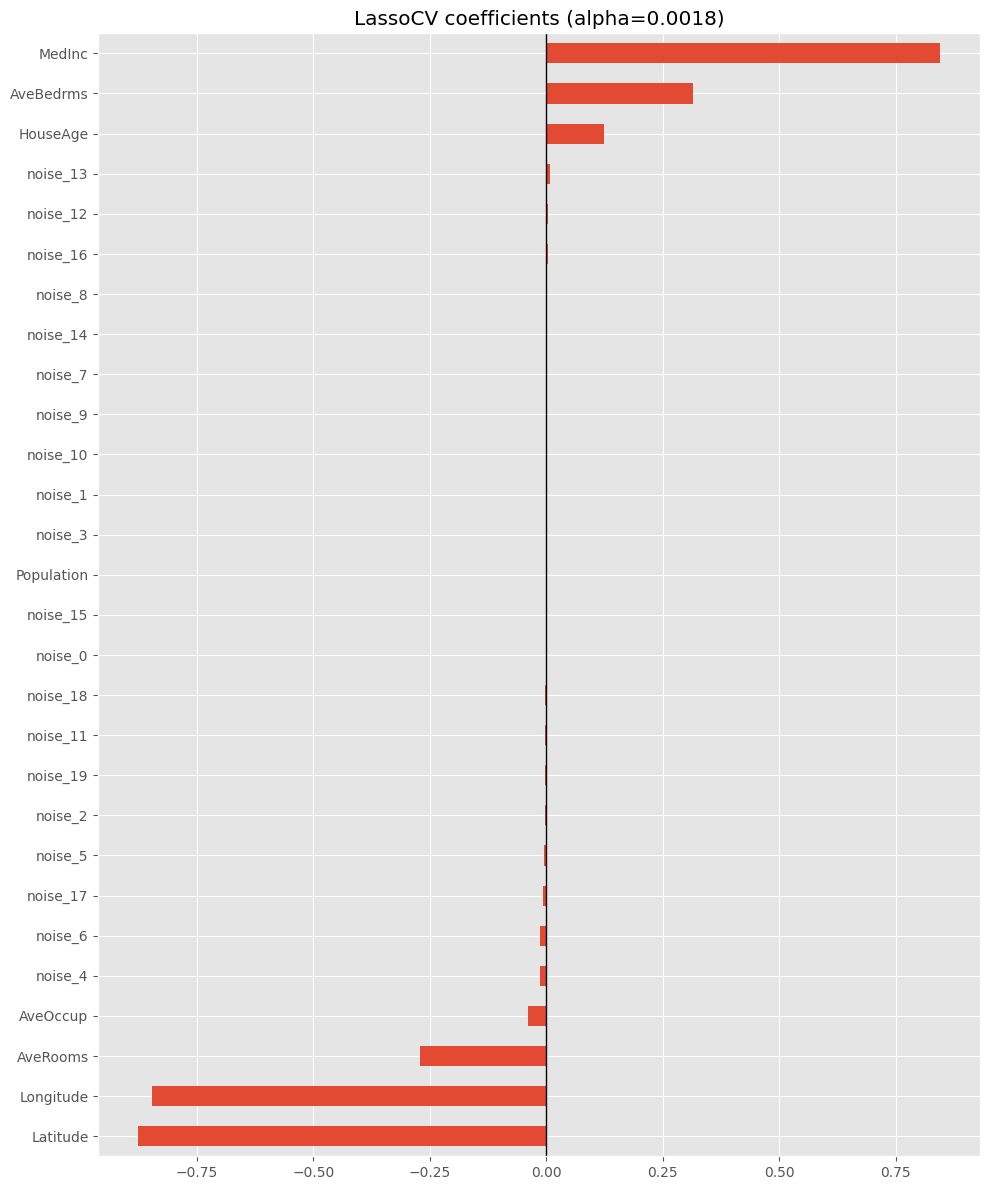

In [31]:
coef_cv.sort_values().plot(kind="barh", figsize=(10, 12))
plt.axvline(0, color="black", linewidth=1)
plt.title(f"LassoCV coefficients (alpha={lasso_cv.alpha_:.4f})")
plt.tight_layout()
plt.show()

係数が 0 になった変数は、グラフ上では見えにくくなる。
そこで、どの変数が残ったかを次に確認する。

---

## 16. 元の特徴量とノイズ特徴量を分けて確認する

LASSO が残した特徴量のうち、元の特徴量と人工ノイズがどうなっているかを確認する。

In [32]:
selected_original = coef_cv.loc[original_features][coef_cv.loc[original_features] != 0]
selected_noise = coef_cv.loc[noise_features][coef_cv.loc[noise_features] != 0]

print("Selected original features:", list(selected_original.index))
print("Number of selected original features:", len(selected_original))
print("Number of selected noise features   :", len(selected_noise))

if len(selected_noise) > 0:
    display(selected_noise.sort_values(key=np.abs, ascending=False))
else:
    print("No noise feature survived LASSO in this run.")

Selected original features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Number of selected original features: 8
Number of selected noise features   : 15


,0
noise_4,-0.013533
noise_6,-0.012813
noise_13,0.007241
noise_17,-0.006890
noise_5,-0.005384
noise_12,0.004153
noise_2,-0.003671
noise_16,0.003560
noise_19,-0.003557
noise_11,-0.003179


ここで見たいのは、

- 元の特徴量はどの程度残ったか
- ノイズ特徴量はどの程度落ちたか
- ノイズ特徴量が残った場合、その係数は大きいか

LASSO は不要変数を落とす傾向があるが、完全に正しい特徴量選択を保証するわけではない。
特に、サンプルサイズ、ノイズの大きさ、特徴量間の相関、`alpha` の選び方によって結果は変わる。

---

## 18. 演習

ここまでは、California housing dataset に人工的なノイズ変数を追加して、OLS, Ridge, LASSO を比較した。
次に、より実データに近い **Ames Housing dataset** を使って分析を行いなさい。

Ames Housing dataset は、米国アイオワ州 Ames の住宅取引データである。
住宅の面積、築年数、品質、ガレージ、地下室、近隣地区、販売条件など、多くの特徴量を持つ。
目的変数は住宅販売価格である。

このデータは、OLS, Ridge, LASSO の比較に向いている。
理由は次の通りである。

- 変数の数が多い
- 数値変数とカテゴリ変数が混在している
- 欠損値が含まれる
- one-hot encoding 後に特徴量数が増える
- LASSO の特徴量選択の効果を確認しやすい

以下のコードは上記のコードを元に、さらにいくつか新しい関数も使った発展版である。これを用いても良いし、自由に変更しても良い。自分の目的に合わせて、変更せよ。

---

### 17.1 データを読み込む

OpenML から Ames Housing dataset を取得する。

In [33]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name="house_prices", as_frame=True)

X_ames = ames.data
y_ames = ames.target.astype(float)

確認する。

In [34]:
print(X_ames.shape)
print(y_ames.shape)

display(X_ames.head())
display(y_ames.head())

(1460, 80)
(1460,)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


,SalePrice
0,208500.0
1,181500.0
2,223500.0
3,140000.0
4,250000.0


目的変数の分布を見る。

In [35]:
y_ames.describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


住宅価格のような変数は右に歪んだ分布になりやすい。
高価格物件が一部に存在するためである。
そこで、ここでは対数を取った住宅価格を目的変数にする。

In [36]:
y_ames_log = np.log(y_ames)

y_ames_log.describe()

,SalePrice
count,1460.000000
mean,12.024051
std,0.399452
min,10.460242
25%,11.775097
50%,12.001505
75%,12.273731
max,13.534473


対数を取ると、極端に高い価格の影響を少し抑えられる。
また、予測誤差を「価格の比率」に近い感覚で扱える。

---

### 17.2 数値変数とカテゴリ変数を分ける

Ames Housing dataset には、数値変数とカテゴリ変数が混在している。
まず、それらを分ける。

In [37]:
numeric_features = X_ames.select_dtypes(include="number").columns
categorical_features = X_ames.select_dtypes(exclude="number").columns

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numeric features: 37
Number of categorical features: 43


数値変数の例を見る。

In [38]:
list(numeric_features)[:10]

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1']

カテゴリ変数の例を見る。

In [39]:
list(categorical_features)[:10]

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1']

カテゴリ変数は、そのまま線形回帰に入れることはできない。
そのため、one-hot encoding によって 0/1 の列に変換する。

---

### 17.3 前処理を定義する

実データでは、欠損値が含まれることが多い。
そこで、次の前処理を行う。

- 数値変数: 欠損値を中央値で補完し、標準化する
- カテゴリ変数: 欠損値を最頻値で補完し、one-hot encoding する

この処理には、`ColumnTransformer` と `Pipeline` を使う。

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

`make_pipeline()` は、複数の処理を順番につなげて 1 つのオブジェクトとして扱うための関数である。
たとえば、数値変数に対して

1. 欠損値を中央値で埋める
2. 標準化する

という 2 つの処理を順番に行いたい場合、次のように書ける。

In [41]:
numeric_preprocess = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

これは、欠損値補完 → 標準化という流れを 1 つにまとめている。

同じように、カテゴリ変数に対して

1. 欠損値を最頻値で埋める
2. one-hot encoding する

という処理も 1 つにまとめられる。

`make_pipeline()` を使う利点は、前処理とモデル学習を同じ流れで管理できることである。
特に、学習データとテストデータを分けた後に、

- 学習データで欠損補完や標準化のルールを学ぶ
- テストデータには、学習データで学んだルールだけを適用する

という処理を安全に行いやすくなる。

たとえば、後で出てくる次のコードは、

```python

pipe = make_pipeline(preprocess, model)
pipe.fit(X_train_ames, y_train_ames)
y_pred_ames = pipe.predict(X_test_ames)

```

以下の処理を順番に行っている。

1. `preprocess` で欠損補完、標準化、one-hot encoding を行う
2. 変換されたデータで `model` を学習する
3. テストデータにも同じ前処理を適用して予測する

このように、`make_pipeline()` は、前処理とモデルをまとめて扱うための道具である。このような一連の操作のことをパイプラインと呼ぶ

数値変数用の前処理を作る。

In [43]:
numeric_preprocess = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

カテゴリ変数用の前処理を作る。

In [44]:
categorical_preprocess = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False)
)

2 つをまとめる。

In [45]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, numeric_features),
        ("cat", categorical_preprocess, categorical_features)
    ]
)

ここで重要なのは、前処理をモデルと一体で扱うことである。
メインのモデル学習の部分だけではなく、前処理部分についてもデータリークについて考えなければならない。
パイプラインにより、データリークを避けやすくなる。

---

### 17.4 学習データとテストデータに分ける

In [46]:
X_train_ames, X_test_ames, y_train_ames, y_test_ames = train_test_split(
    X_ames,
    y_ames_log,
    test_size=0.2,
    random_state=42
)

確認する。

In [47]:
print(X_train_ames.shape, y_train_ames.shape)
print(X_test_ames.shape, y_test_ames.shape)

(1168, 80) (1168,)
(292, 80) (292,)


---

### 17.5 OLS, Ridge, LASSO を比較する

前処理とモデルを `Pipeline` でまとめる。

In [48]:
ames_models = {
    "OLS": LinearRegression(),
    "Ridge(alpha=10.0)": Ridge(alpha=10.0),
    "Lasso(alpha=0.001)": Lasso(alpha=0.001, max_iter=20000)
}

学習、予測、評価をまとめて行う。

In [49]:
ames_results = []
ames_coef_dict = {}

for name, model in ames_models.items():
    pipe = make_pipeline(preprocess, model)
    pipe.fit(X_train_ames, y_train_ames)
    y_pred_ames = pipe.predict(X_test_ames)

    fitted_model = pipe[-1]
    feature_names = pipe[0].get_feature_names_out()
    coef = pd.Series(fitted_model.coef_, index=feature_names)

    ames_results.append({
        "model": name,
        "RMSE_log": np.sqrt(mean_squared_error(y_test_ames, y_pred_ames)),
        "R2": r2_score(y_test_ames, y_pred_ames),
        "nonzero_coef": int((coef != 0).sum()),
        "zero_coef": int((coef == 0).sum())
    })

    ames_coef_dict[name] = coef

ames_results_df = pd.DataFrame(ames_results)
ames_coef_df = pd.DataFrame(ames_coef_dict)

display(ames_results_df)

,model,RMSE_log,R2,nonzero_coef,zero_coef
0,OLS,0.127985,0.912224,287,0
1,Ridge(alpha=10.0),0.135866,0.901081,287,0
2,Lasso(alpha=0.001),0.137417,0.898809,82,205


見るべき点は次の通りである。

- OLS, Ridge, LASSO の RMSE はどう違うか
- LASSO では 0 になった係数がどのくらいあるか
- Ridge では係数が 0 になるか

---

### 17.6 LASSO が残した特徴量を見る

LASSO の係数を取り出す。

In [50]:
lasso_ames_coef = ames_coef_df["Lasso(alpha=0.001)"]

絶対値が大きい特徴量を確認する。

In [51]:
lasso_ames_coef.sort_values(key=np.abs, ascending=False).head(30)

,Lasso(alpha=0.001)
cat__RoofMatl_ClyTile,-0.411966
num__GrLivArea,0.102668
cat__Neighborhood_Crawfor,0.087735
num__OverallQual,0.085429
cat__Neighborhood_StoneBr,0.082892
cat__Exterior1st_BrkFace,0.079701
cat__Neighborhood_NridgHt,0.060274
cat__MSZoning_RM,-0.056971
cat__Functional_Typ,0.052370
cat__Condition1_Norm,0.050537


0 でない係数だけを取り出す。

In [52]:
selected_ames_features = lasso_ames_coef[lasso_ames_coef != 0]

print("Number of selected features:", len(selected_ames_features))
print("Number of removed features :", int((lasso_ames_coef == 0).sum()))

Number of selected features: 82
Number of removed features : 205


可視化する。

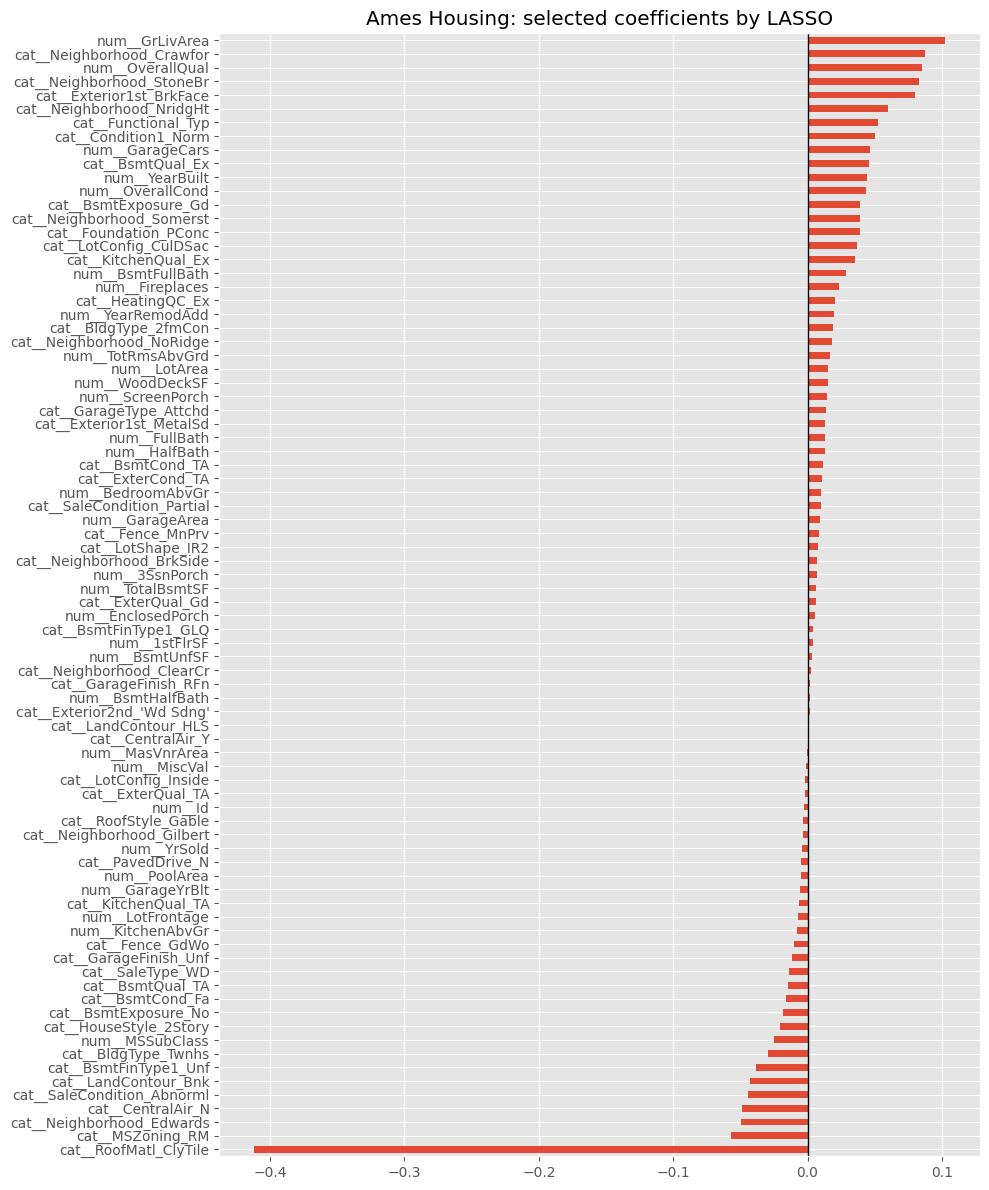

In [53]:
selected_ames_features.sort_values().plot(kind="barh", figsize=(10, 12))
plt.axvline(0, color="black", linewidth=1)
plt.title("Ames Housing: selected coefficients by LASSO")
plt.tight_layout()
plt.show()

この結果から、どの特徴量が住宅価格予測に強く関係していそうかを確認する。

---

### 17.7 LassoCV で alpha を選ぶ

Ames Housing でも、`alpha` を手で決めるのではなく、Cross-validationで選んでみる。

In [54]:
lasso_cv_ames_pipe = make_pipeline(
    preprocess,
    LassoCV(cv=5, random_state=42, max_iter=20000)
)

lasso_cv_ames_pipe.fit(X_train_ames, y_train_ames)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',...
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('lassocv', LassoCV(cv=5, max_iter=20000, random_state=42))])

予測と評価を行う。

In [55]:
y_pred_ames_cv = lasso_cv_ames_pipe.predict(X_test_ames)
lasso_cv_ames = lasso_cv_ames_pipe[-1]

print("Best alpha:", lasso_cv_ames.alpha_)
print("Test RMSE_log:", np.sqrt(mean_squared_error(y_test_ames, y_pred_ames_cv)))
print("Test R2      :", r2_score(y_test_ames, y_pred_ames_cv))

Best alpha: 0.0007814068591300522
Test RMSE_log: 0.13506511778135494
Test R2      : 0.9022440270535059


CV 誤差パスを見る。

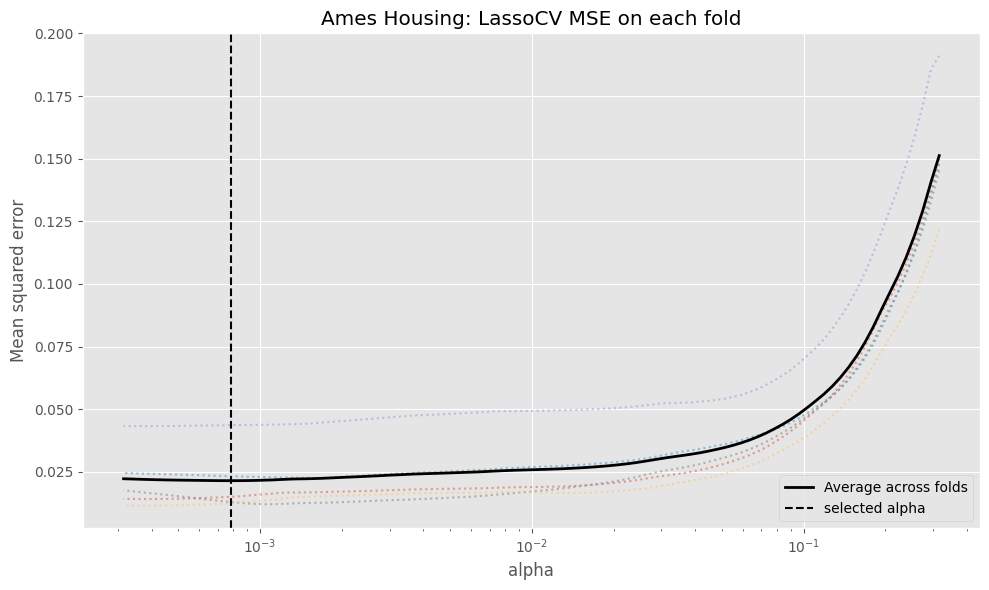

In [56]:
plt.figure(figsize=(10, 6))

plt.semilogx(lasso_cv_ames.alphas_, lasso_cv_ames.mse_path_, ":", alpha=0.5)
plt.semilogx(
    lasso_cv_ames.alphas_,
    lasso_cv_ames.mse_path_.mean(axis=1),
    color="black",
    linewidth=2,
    label="Average across folds"
)
plt.axvline(
    lasso_cv_ames.alpha_,
    linestyle="--",
    color="black",
    label="selected alpha"
)

plt.xlabel("alpha")
plt.ylabel("Mean squared error")
plt.title("Ames Housing: LassoCV MSE on each fold")
plt.legend()
plt.tight_layout()
plt.show()

California housing に人工ノイズを入れた例と比べて、Ames Housing はより実データに近い。
カテゴリ変数、欠損値、one-hot encoding が入るため、前処理とモデルを `Pipeline` でまとめる重要性も確認できる。

ただし、上記の分析だけでは、まだ何を主要結果とすべきか、何を検証したのかはよく分からない。どのように分析を修正すべきか、考えよ。
